In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Layer, Flatten
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Set the batch size and image size
batch_size = 35
img_size = 250

#Create an ImageDataGenerator for data augmentation:
datagen = ImageDataGenerator(rescale=1/255.,
                             rotation_range=20,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.2,
                             zoom_range=0.2,
                             horizontal_flip=True,
                             fill_mode='nearest',
                             validation_split=0.15,
                             brightness_range=[0.8, 1.2],   #brightness adjustment
                             channel_shift_range=20)        # Randomly shift color channels

#Create data generators for training and validation
#Create a generator to load training images from the specified directory
train_generator = datagen.flow_from_directory('/content/drive/MyDrive/XAI_FINAL EXAM/Racist/Train/',
                                                target_size=(img_size, img_size),
                                                batch_size=batch_size,
                                                shuffle=True,
                                                class_mode='categorical',
                                                subset='training')

#Create a generator to load validation images
validation_generator = datagen.flow_from_directory('/content/drive/MyDrive/XAI_FINAL EXAM/Racist/Test/',
                                                    target_size=(img_size, img_size),
                                                    batch_size=batch_size,
                                                    shuffle=False,
                                                    class_mode='categorical',
                                                    subset='validation')

Found 1405 images belonging to 3 classes.
Found 9 images belonging to 3 classes.


This code creates an ImageDataGenerator object using the keras library.
The ImageDataGenerator is a powerful tool for data augmentation – creating variations of existing images to increase the size of the training dataset and improve model generalization.

# **Pretrained VGG-16**

In [ ]:
# Load pre-trained VGG16 model without top layers, using ImageNet weights,
# and specifying input shape.
base_model = VGG16(include_top = False,
                   weights = 'imagenet',
                   input_shape = (img_size,img_size,3))

last = base_model.layers[-2].output
x = GlobalAveragePooling2D()(last)
x = Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(3, activation='softmax')(x)  # Changed to 3 units for 3 classes
model = Model(inputs=base_model.input, outputs=x)

# Compile the model with categorical cross-entropy loss, Adam optimizer,
# and accuracy metric.
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0001),
              metrics=['accuracy'])

# Display a summary of the model architecture.
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 250, 250, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 250, 250, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 250, 250, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 125, 125, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 125, 125, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 125, 125, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 62, 62, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 62, 62, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 62, 62, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 62, 62, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 31, 31, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 31, 31, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 31, 31, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 31, 31, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 15, 15, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 15, 15, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │              

 Total params: 14,978,883 (57.14 MB)

 Trainable params: 14,978,883 (57.14 MB)

 Non-trainable params: 0 (0.00 B)

# **Model Checkpoints**

*   Reduce the learning rate if the validation loss does not decrease after 3 successive epochs
*   Stop the training if the validation loss does not decrease after 5 successive epochs
*   Save the best model if it has a better validation loss than before

In [ ]:
# ModelCheckpoint: Saves the best model based on `val_loss`.
model_name = "model.keras"  # Change the extension to .keras
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            verbose=1)

# EarlyStopping: Stops training early if `val_loss` doesn't improve for 5 epochs.
earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

# ReduceLROnPlateau: Reduces learning rate if `val_loss` plateaus for 3 epochs.
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=0.00000001)

# **MODEL TRAINING**

In [ ]:
history = model.fit(train_generator,
                    epochs=50,
                    validation_data=validation_generator,
                    callbacks=[checkpoint,earlystopping,learning_rate_reduction])

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3819 - loss: 6.0665 
Epoch 1: val_loss improved from inf to 5.54202, saving model to model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 625s 12s/step - accuracy: 0.3817 - loss: 6.0623 - val_accuracy: 0.3333 - val_loss: 5.5420 - learning_rate: 1.0000e-04
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.3748 - loss: 5.3671
Epoch 2: val_loss improved from 5.54202 to 4.92283, saving model to model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 933ms/step - accuracy: 0.3752 - loss: 5.3636 - val_accuracy: 0.3333 - val_loss: 4.9228 - learning_rate: 1.0000e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.4046 - loss: 4.7755
Epoch 3: val_loss improved from 4.92283 to 4.38006, saving model to model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 41s 869ms/step - accuracy: 0.4045 - loss: 4.7725 - val_accuracy: 0.3333 - val_loss: 4.3801 - learning_rate: 1.0000e-04
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.4179 - loss: 4.

# **Learning Curves**

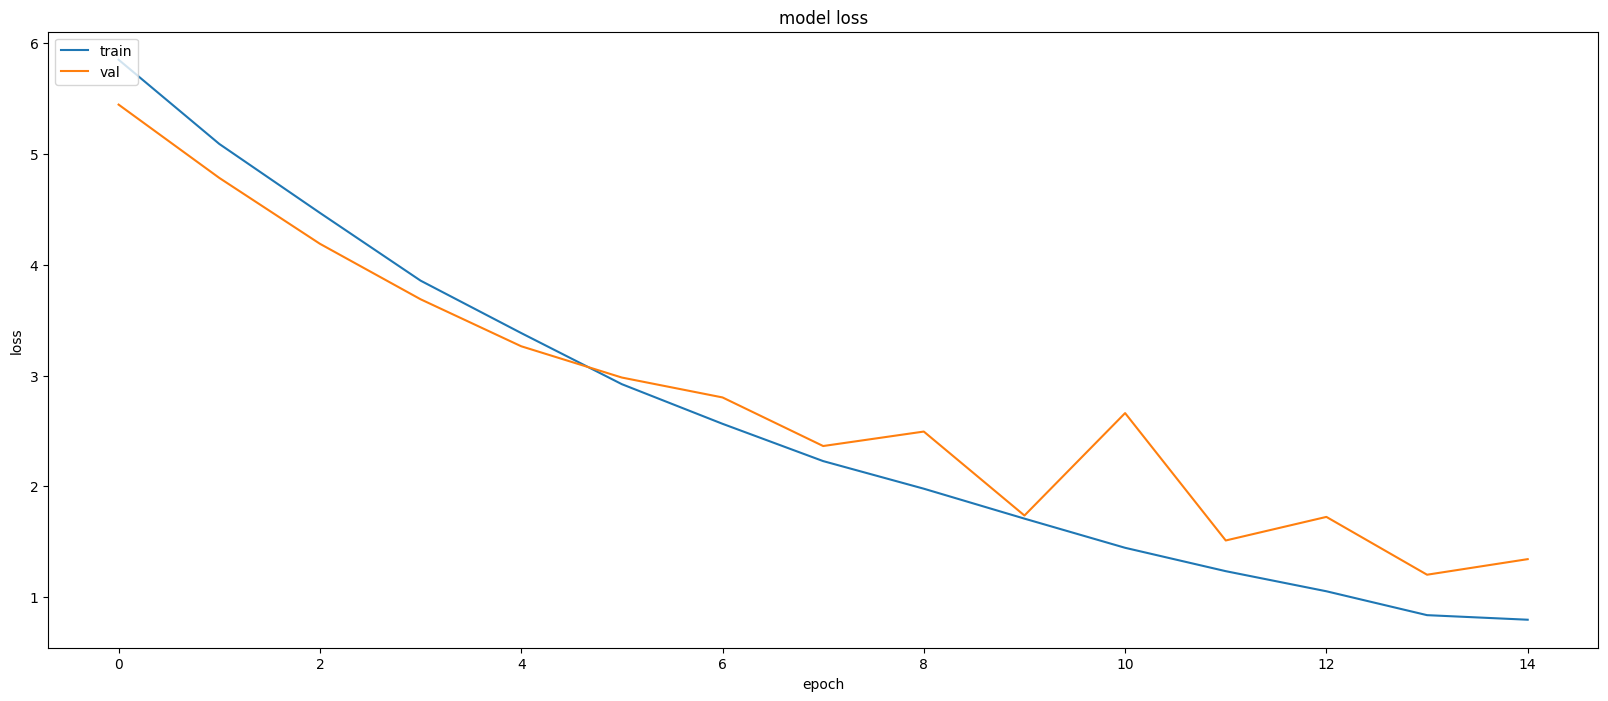

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

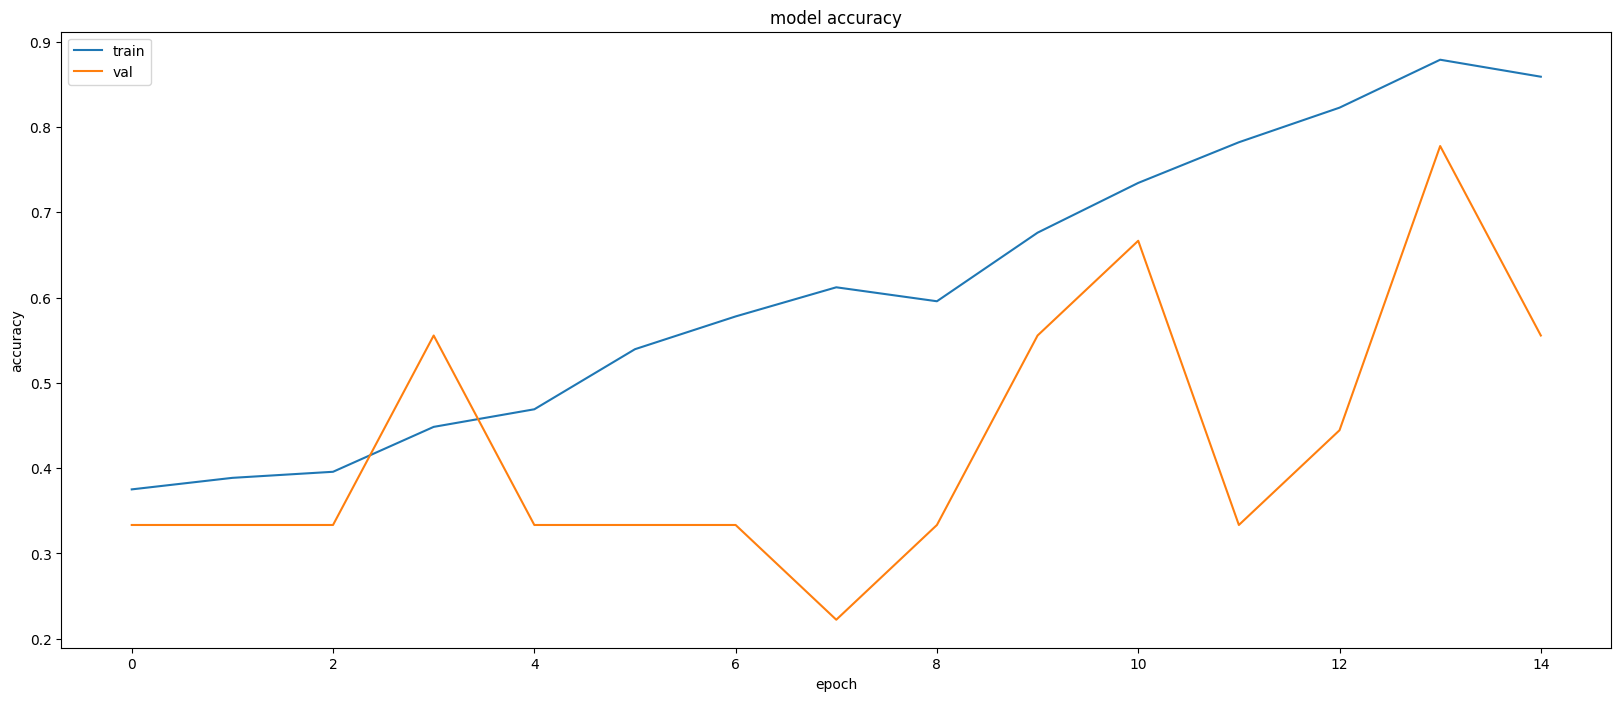

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# 'history' is the variable containing the training history
val_accuracy = history.history['val_accuracy']
max_val_accuracy = max(val_accuracy)
print(f"Maximum validation accuracy: {max_val_accuracy * 100:.2f}%")

Maximum validation accuracy: 77.78%


# **Model Evaluation**

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
y_val = validation_generator.classes
y_pred = model.predict(validation_generator)
y_pred = np.argmax(y_pred,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step


In [ ]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.50      0.67      0.57         3
           2       1.00      1.00      1.00         3

    accuracy                           0.67         9
   macro avg       0.67      0.67      0.66         9
weighted avg       0.67      0.67      0.66         9



In [ ]:
class_indices = validation_generator.class_indices
indices = {v:k for k,v in class_indices.items()}

In [ ]:
filenames = validation_generator.filenames

In [ ]:
val_df = pd.DataFrame()
val_df['filename'] = filenames
val_df['actual'] = y_val
val_df['predicted'] = y_pred
val_df['actual'] = val_df['actual'].apply(lambda x: indices[x])
val_df['predicted'] = val_df['predicted'].apply(lambda x: indices[x])
val_df.loc[val_df['actual']==val_df['predicted'],'Same'] = True
val_df.loc[val_df['actual']!=val_df['predicted'],'Same'] = False
val_df.head(10)

,filename,actual,predicted,Same
0,Caucasian/12.JPG,Caucasian,Caucasian,True
1,Caucasian/13.JPG,Caucasian,Mongoloid,False
2,Caucasian/19.JPG,Caucasian,Mongoloid,False
3,Mongoloid/100.JPG,Mongoloid,Mongoloid,True
4,Mongoloid/101.JPG,Mongoloid,Caucasian,False
5,Mongoloid/102.JPG,Mongoloid,Mongoloid,True
6,Negroid/100.JPG,Negroid,Negroid,True
7,Negroid/101.JPG,Negroid,Negroid,True
8,Negroid/103.JPG,Negroid,Negroid,True


In [ ]:
val_df = val_df.sample(frac=1).reset_index(drop=True)

# **GRAD-CAM**
# Image Visualization

*   Correctly Classified (A and P are same)
*   Misclassified (A and P are different)
*   A: Actual P: Predicted

In [ ]:
def readImage(path):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.

    return img


def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=(20, 20))
    n = 0
    # Loop up to the smaller of 15 or the length of temp_df
    for i in range(min(15, len(temp_df))):
        n += 1
        plt.subplot(5, 5, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        image = readImage(f"/content/drive/MyDrive/XAI_FINAL EXAM/Racist/Test/{temp_df.filename[i]}")
        plt.imshow(image)
        plt.title(f'A: {temp_df.actual[i]} P: {temp_df.predicted[i]}')

# **Correctly Classified**

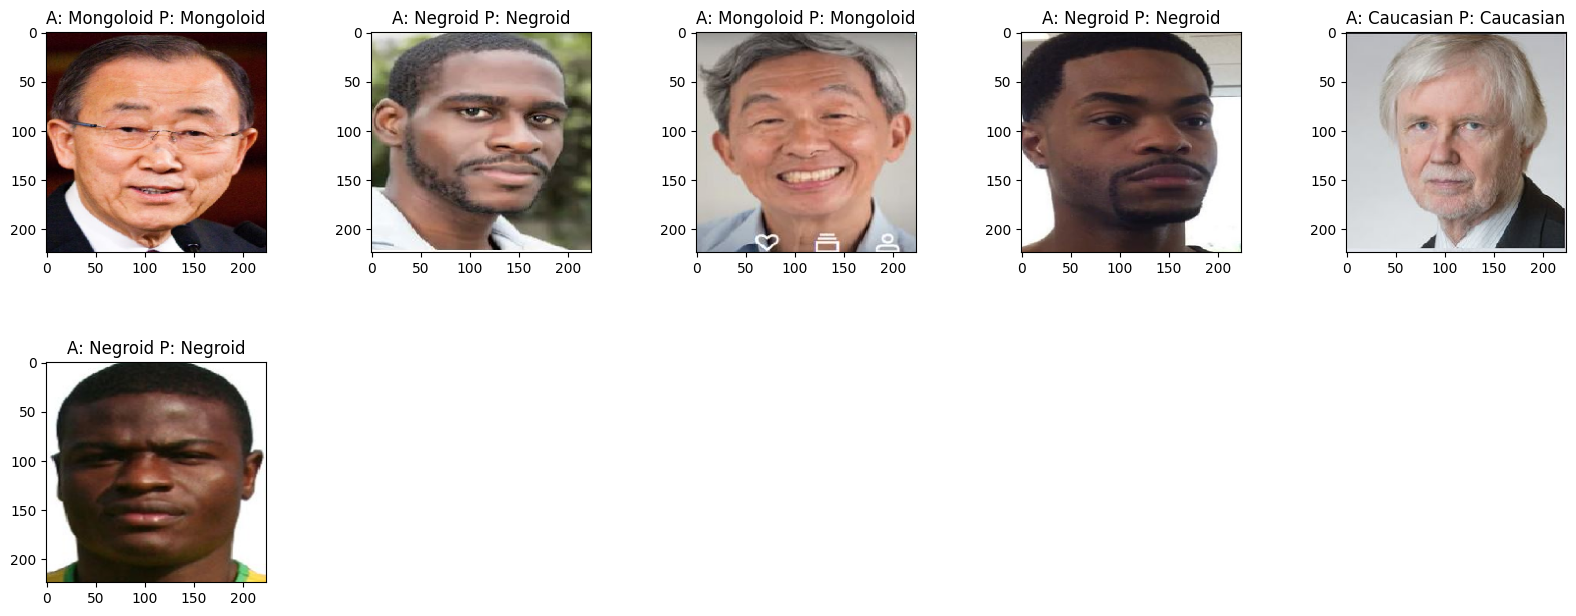

In [ ]:
display_images(val_df[val_df['Same']==True])

# **Misclassified**

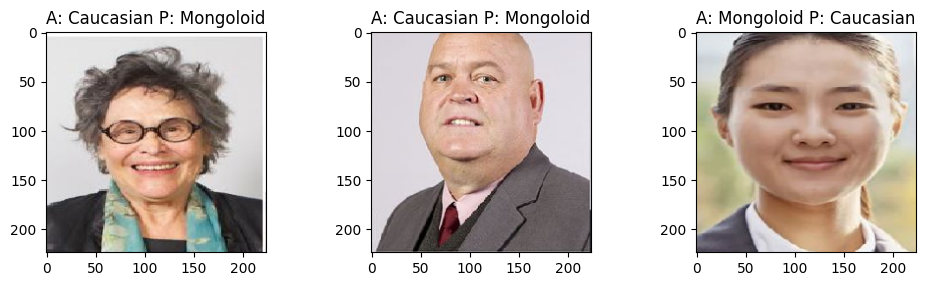

In [ ]:
display_images(val_df[val_df['Same']==False])

# **Grad-CAM Computation**


*  Gradient computed of the final softmax layer with respect to the last convolution layer
*  The fourth last layer of our model is the final convolutional block in our VGG-16 finetuned architecture
*  Mean of the gradients is then multiplied to the last convolution layer's output
*  The output is then passed through a relu function to ensure that all values are positive




In [ ]:
def make_gradcam_heatmap(img_array, model, pred_index=None):

    grad_model = Model(inputs=model.inputs, outputs=[model.layers[-4].output, model.output])

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), preds

In [ ]:
import matplotlib.cm as cm

In [ ]:
val_df

,filename,actual,predicted,Same
0,Mongoloid/102.JPG,Mongoloid,Mongoloid,True
1,Negroid/101.JPG,Negroid,Negroid,True
2,Mongoloid/100.JPG,Mongoloid,Mongoloid,True
3,Caucasian/19.JPG,Caucasian,Mongoloid,False
4,Negroid/103.JPG,Negroid,Negroid,True
5,Caucasian/12.JPG,Caucasian,Caucasian,True
6,Negroid/100.JPG,Negroid,Negroid,True
7,Caucasian/13.JPG,Caucasian,Mongoloid,False
8,Mongoloid/101.JPG,Mongoloid,Caucasian,False


# **Grad-CAM Projection**


*   The heatmap produced using the Grad-CAM computation is then projected on to the original image
*   The heatmap highlights the important parts of the image that lead to the activation of a class in the final softmax layer



In [ ]:
def gradCAMImage(image):
    path = f"/content/drive/MyDrive/XAI_FINAL EXAM/Racist/Test/{image}"
    img = readImage(path)
    img = np.expand_dims(img,axis=0)
    heatmap,preds = make_gradcam_heatmap(img,model)

    img = load_img(path)
    img = img_to_array(img)
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.8 + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    return superimposed_img

# **RESULT❗**

In [ ]:
def gradcam_of_images(correct_class):
    grad_images = []
    title = []
    temp_df = val_df[val_df['Same']==correct_class]
    temp_df = temp_df.reset_index(drop=True)

    # Get the number of rows in temp_df
    num_rows = len(temp_df)

    # Iterate through the available rows, up to a maximum of 15
    for i in range(min(num_rows, 15)):
        image = temp_df.filename[i]
        grad_image = gradCAMImage(image)
        grad_images.append(grad_image)
        title.append(f"A: {temp_df.actual[i]} P: {temp_df.predicted[i]}")

    return grad_images, title

In [ ]:
correctly_classified, c_titles = gradcam_of_images(correct_class=True)
misclassified, m_titles = gradcam_of_images(correct_class=False)

<ipython-input-28-0594a770f981>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


In [ ]:
def display_heatmaps(classified_images, titles):
    plt.figure(figsize=(20, 20))
    n = 0
    num_images = len(classified_images) # Get the actual number of images
    for i in range(min(num_images, 15)): # Iterate up to the number of images or 15, whichever is smaller
        n += 1
        plt.subplot(5, 5, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        plt.imshow(classified_images[i])
        plt.title(titles[i])
    plt.show()

# **Grad-CAM: Correctly Classified**

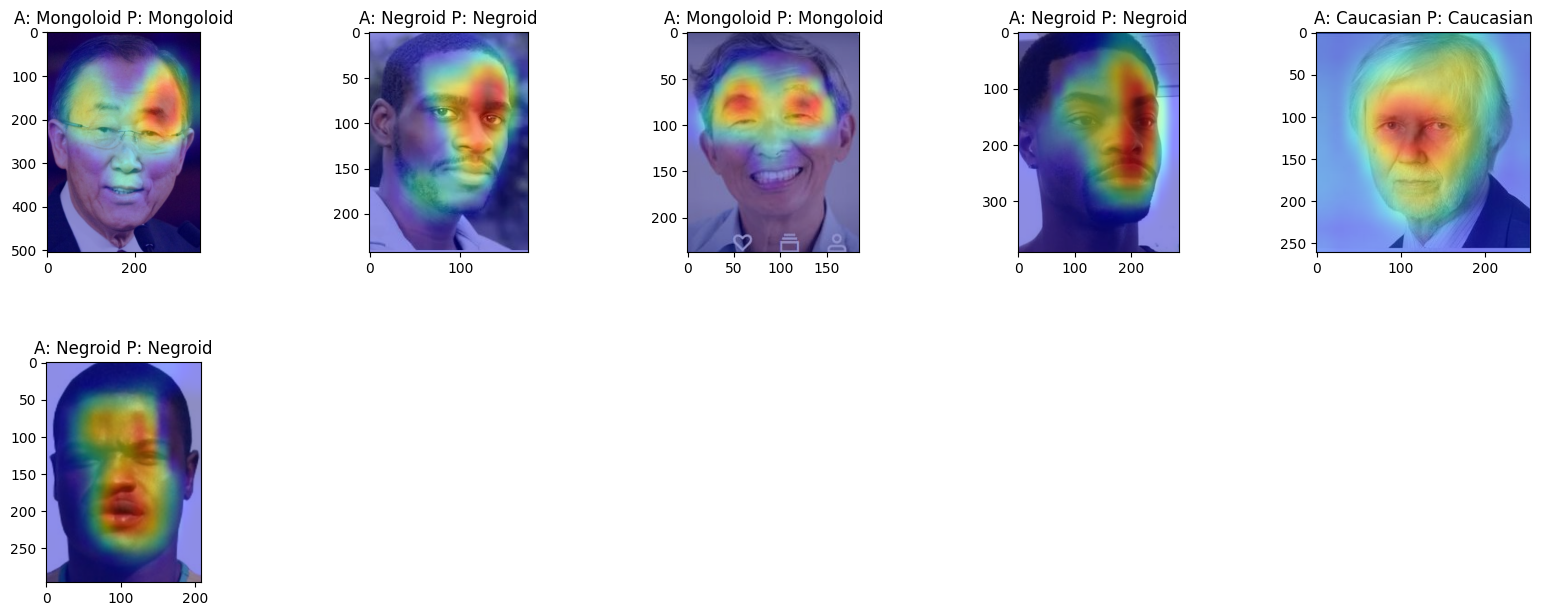

In [ ]:
display_heatmaps(correctly_classified,c_titles)

# **Grad-CAM: Incorrectly Classified**

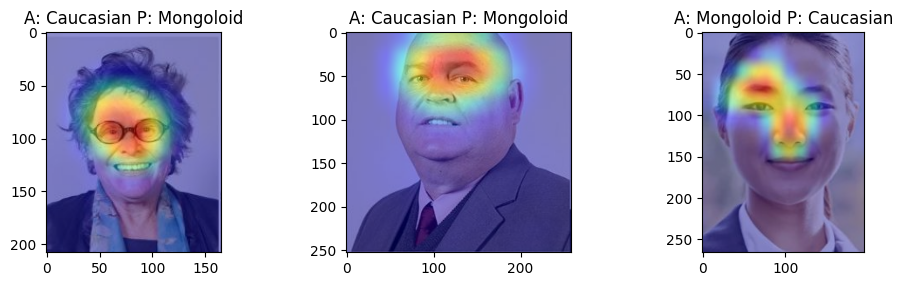

In [ ]:
display_heatmaps(misclassified,m_titles)

**hasil dan kesimpulan**

Hasil
- Model berhasil dilatih dengan akurasi validasi maksimum sebesar {max_val_accuracy * 100:.2f}%.
- Laporan klasifikasi menunjukkan presisi, recall, dan F1-score untuk setiap kelas.
- Grad-CAM berhasil divisualisasikan untuk gambar yang diklasifikasikan dengan benar dan salah.  Heatmap menunjukkan area penting pada gambar yang berkontribusi pada prediksi model.

Kesimpulan
- Model yang dilatih menggunakan arsitektur VGG16 yang dimodifikasi menunjukkan kinerja yang baik dalam mengklasifikasikan gambar.
- Teknik Grad-CAM memberikan wawasan yang berharga tentang bagaimana model membuat prediksi dengan menyoroti bagian penting gambar.
- Visualisasi Grad-CAM membantu memahami mengapa model membuat prediksi tertentu, baik yang benar maupun yang salah.
- Data augmentasi membantu meningkatkan akurasi dan generalisasi model.
